In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression

In [4]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
import seaborn as sns

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [8]:
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_auc_score)

In [9]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(1470, 35)
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWork

In [10]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [11]:
for col in df.columns:
    if df[col].dtypes == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [12]:
print(df.select_dtypes(include='object').columns)

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


In [13]:
for col in df.columns:
    if df[col].dtype == 'object' and df[col].nunique() >= 3:
        df = pd.get_dummies(df, columns=[col], drop_first=True)
    elif df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

In [14]:
print(df.shape)
df.dtypes

(1470, 49)


Age                                  int64
Attrition                            int64
DailyRate                            int64
DistanceFromHome                     int64
Education                            int64
EmployeeCount                        int64
EmployeeNumber                       int64
EnvironmentSatisfaction              int64
Gender                               int64
HourlyRate                           int64
JobInvolvement                       int64
JobLevel                             int64
JobSatisfaction                      int64
MonthlyIncome                        int64
MonthlyRate                          int64
NumCompaniesWorked                   int64
Over18                               int64
OverTime                             int64
PercentSalaryHike                    int64
PerformanceRating                    int64
RelationshipSatisfaction             int64
StandardHours                        int64
StockOptionLevel                     int64
TotalWorkin

In [15]:
df.drop(columns = "Over18", inplace = True)

In [16]:
for col in df.columns:
    if df[col].dtype == 'object' and df[col].nunique() >= 3:
        df = pd.get_dummies(df, columns=[col], drop_first=True)
    elif df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

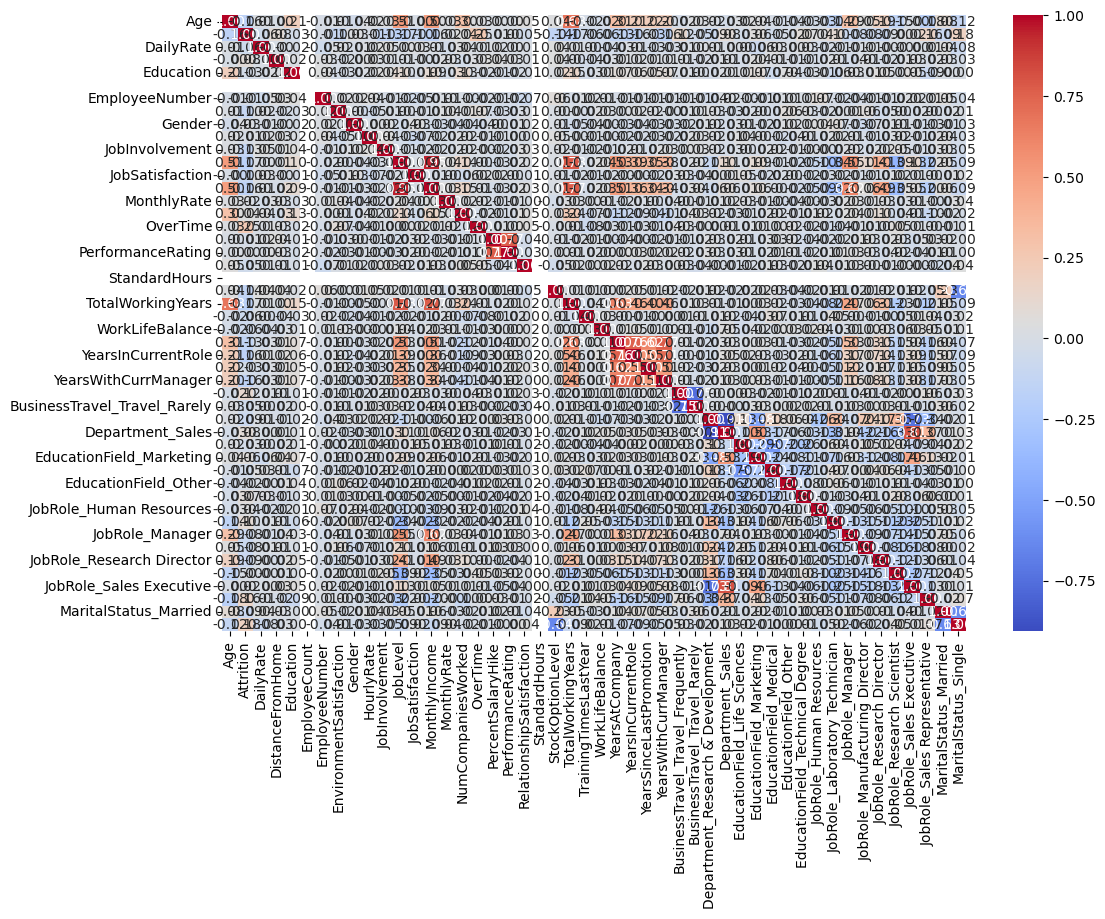

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [18]:
corr_matrix = df.corr().abs()

# get upper triangle only to avoid duplicates
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# find columns with correlation above 0.9
high_corr = [col for col in upper.columns if any(upper[col] > 0.9)]
print(high_corr)

['MonthlyIncome', 'Department_Sales']


In [19]:
corr_matrix = df.corr().abs()

print(corr_matrix["MonthlyIncome"].sort_values(ascending=False).head(10))
print(corr_matrix["Department_Sales"].sort_values(ascending=False).head(10))

MonthlyIncome                 1.000000
JobLevel                      0.950300
TotalWorkingYears             0.772893
JobRole_Manager               0.619573
YearsAtCompany                0.514285
Age                           0.497855
JobRole_Research Director     0.485818
YearsInCurrentRole            0.363818
JobRole_Research Scientist    0.345180
YearsSinceLastPromotion       0.344978
Name: MonthlyIncome, dtype: float64
Department_Sales                     1.000000
Department_Research & Development    0.906818
JobRole_Sales Executive              0.808869
EducationField_Marketing             0.527691
JobRole_Sales Representative         0.370667
JobRole_Research Scientist           0.328576
JobRole_Laboratory Technician        0.305208
JobRole_Manufacturing Director       0.218320
EducationField_Medical               0.168034
JobRole_Research Director            0.158327
Name: Department_Sales, dtype: float64


In [20]:
df.drop(columns=["JobLevel"], inplace=True)

In [21]:
X = df.drop(columns = ["Attrition"])
y= df["Attrition"]

In [22]:
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
num_cols = [col for col in X_train.columns if X_train[col].dtypes == "float64" or X_train[col].dtypes == "int64"]

In [24]:
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [25]:
model = LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced')
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.79      0.85       247
           1       0.37      0.66      0.47        47

    accuracy                           0.77       294
   macro avg       0.65      0.72      0.66       294
weighted avg       0.84      0.77      0.79       294



In [26]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': np.abs(model.coef_[0])
}).sort_values('Coefficient', ascending=False).head(10)

print(coef_df)

                             Feature  Coefficient
27  BusinessTravel_Travel_Frequently     1.571903
37     JobRole_Laboratory Technician     1.412028
40         JobRole_Research Director     1.167434
43      JobRole_Sales Representative     1.165079
34              EducationField_Other     0.979934
45              MaritalStatus_Single     0.893547
28      BusinessTravel_Travel_Rarely     0.873130
14                          OverTime     0.746561
36           JobRole_Human Resources     0.568037
20                 TotalWorkingYears     0.523922


In [27]:
results_df = X_test.copy()
results_df['Actual'] = y_test.values
results_df['Predicted'] = y_pred

coef_df.to_csv('hr_feature_importance.csv', index=False)
results_df.to_csv('hr_predictions.csv', index=False)

print("Exported")

Exported
